In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
path = r"D:\project1\dataset\raw data\\"
production = pd.read_csv(path + "production fact(1).csv")
downtime = pd.read_csv(path + "Downtime fact.csv")
maintenance = pd.read_csv(path + "Maintenance fact.csv")

machines = pd.read_csv(path + "machine dim.csv")
plants = pd.read_csv(path + "Plants dimension table.csv")
operators = pd.read_csv(path + "operaters dim.csv")
products = pd.read_csv(path + "product dim.csv")

print("All tables loaded ✅")

All tables loaded ✅


In [12]:
production['date'] = pd.to_datetime(production['date'])
downtime['date'] = pd.to_datetime(downtime['date'])

maintenance['maintainance_date'] = pd.to_datetime(
    maintenance['maintainance_date']
)

print("Dates converted ✅")

Dates converted ✅


In [14]:
#Create Efficiency & Rejection Rate
production['efficiency'] = (
    production['actual_units'] /
    production['target_units']
) * 100

production['rejection_rate'] = (
    production['rejected_units'] /
    production['actual_units']
) * 100

print(production[['efficiency', 'rejection_rate']])

     efficiency  rejection_rate
0     96.887160        1.204819
1     96.601942        2.512563
2     99.009901        2.000000
3     95.545657        1.398601
4     96.262534        1.704545
..          ...             ...
994   96.969697        2.678571
995   98.449612        2.887139
996   99.812383        1.503759
997  102.964960        2.356021
998  104.390244        2.803738

[999 rows x 2 columns]


In [25]:
merged = production.merge(plants, on='plant_id', how='left')
merged = merged.merge(machines, on=['machine_id','plant_id'], how='left')
merged = merged.merge(operators, on='operator_id', how='left')
merged = merged.merge(products, on='product_id', how='left')

print("Merged dataset shape:", merged.shape)
merged.head()

Merged dataset shape: (999, 35)


,production_id,product_id,date,plant_id_x,machine_id,operator_id,shift,production_hours,target_units,actual_units,...,plant_id_y,experience_years,shift_prefence,certifications_level,joining_date,product_name,catogary,Unit_price,standard_production_time_minutes,defect_tolerance_percentage
0,1,4,2025-03-16,5,7,69,Evening,10,257,249,...,2,2.7,Night,Intermediate,10-07-2025,Plastic Casing,Industrial,860,26,3
1,2,5,2025-08-05,5,18,5,Night,9,206,199,...,1,14.4,Morning,Beginner,8/25/2017,Control Panel,Automotive,9882,10,5
2,3,5,2025-09-24,2,17,58,general,10,202,200,...,6,6.5,Evening,NaN,1/21/2017,Control Panel,Automotive,9882,10,5
3,4,8,2025-09-22,5,12,61,Morning,11,449,429,...,4,11.2,general,Beginner,11/27/2024,Bearing Component,Electrical,7762,24,5
4,5,4,2026-02-08,1,8,31,Evening,6,1097,1056,...,1,13.2,general,NaN,1/31/2022,Plastic Casing,Industrial,860,26,3


plant_name
Bangalore Plant    129205
Chennai Plant      112750
Hyderabad Plant    105266
Mysore Plant       121652
Pune Plant         120052
mumbai plant       106724
Name: actual_units, dtype: int64


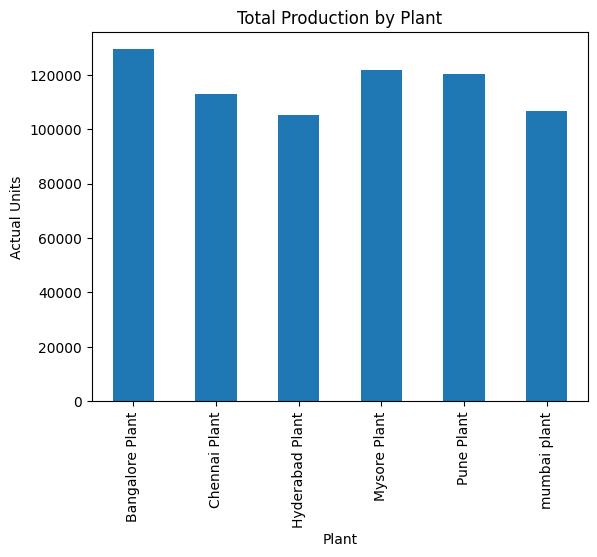

In [ ]:
#Production by Plant
plant_production = merged.groupby('plant_name')['actual_units'].sum()

print(plant_production)

plant_production.plot(kind='bar')
plt.title("Total Production by Plant")
plt.xlabel("Plant")
plt.ylabel("Actual Units")
plt.show()

machine_name
Injection Molding    22582
CNC Machine          16456
Drilling Machine     14904
Laser Cutter         14788
Assembly Robot       13646
Hydraulic Press      12343
Packaging Machine    10418
Name: actual_units, dtype: int64


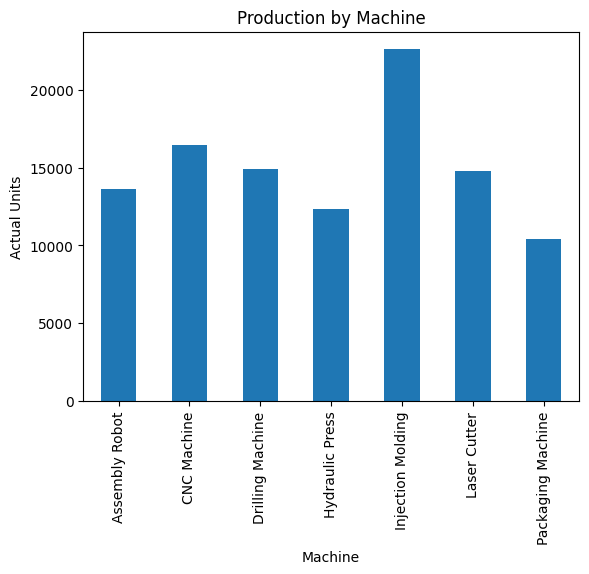

In [ ]:
#Machine Performance
machine_production = merged.groupby('machine_name')['actual_units'].sum()

print(machine_production.sort_values(ascending=False))

machine_production.plot(kind='bar')
plt.title("Production by Machine")
plt.xlabel("Machine")
plt.ylabel("Actual Units")
plt.show()

machine_id
21    4589
31    3768
7     3764
39    3599
6     3569
40    3381
15    3375
4     3277
12    3248
33    3180
34    2986
30    2950
3     2918
8     2875
10    2856
2     2837
29    2758
16    2715
43    2602
19    2574
37    2563
38    2535
20    2479
9     2441
24    2407
35    2394
28    2326
13    2321
27    2315
11    2190
32    2171
41    2093
1     2093
26    2089
36    2077
14    2041
22    2037
44    2021
25    1995
23    1871
18    1867
45    1865
42    1823
17    1801
5     1532
Name: downtime_minutes, dtype: int64


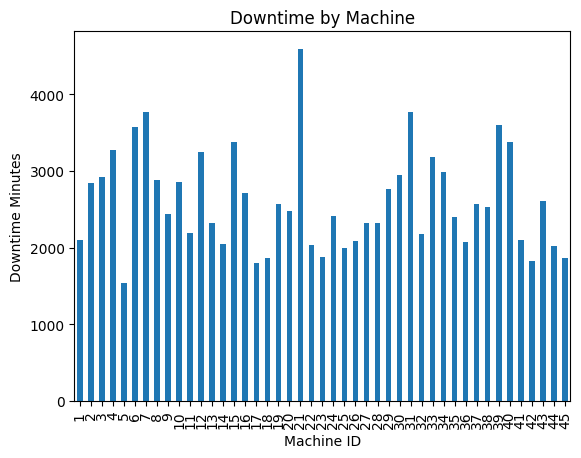

In [28]:
downtime_machine = downtime.groupby('machine_id')['downtime_minutes'].sum()

print(downtime_machine.sort_values(ascending=False))

downtime_machine.plot(kind='bar')
plt.title("Downtime by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Downtime Minutes")
plt.show()

In [31]:
production['machine_id'] = production['machine_id'].astype(str)
downtime['machine_id'] = downtime['machine_id'].astype(str)
prod_down = production.merge(
    downtime,
    on=['machine_id', 'date'],
    how='left'
)
prod_down['downtime_minutes'] = prod_down['downtime_minutes'].fillna(0)
print(prod_down.head())
correlation = prod_down[['actual_units', 'downtime_minutes']].corr()

print(correlation)

   production_id product_id       date plant_id_x machine_id operator_id  \
0              1          4 2025-03-16          5          7          69   
1              2          5 2025-08-05          5         18           5   
2              3          5 2025-09-24          2         17          58   
3              4          8 2025-09-22          5         12          61   
4              5          4 2026-02-08          1          8          31   

   shift_x  production_hours  target_units  actual_units  rejected_units  \
0  Evening                10           257           249               3   
1    Night                 9           206           199               5   
2  general                10           202           200               4   
3  Morning                11           449           429               6   
4  Evening                 6          1097          1056              18   

   efficiency  rejection_rate  downtime_id  plant_id_y  shift_y  \
0   96.887160      

month
2025-02    11034
2025-03    68854
2025-04    50577
2025-05    46212
2025-06    64205
2025-07    62954
2025-08    71193
2025-09    57769
2025-10    64294
2025-11    57816
2025-12    51795
2026-01    51974
2026-02    36972
Freq: M, Name: actual_units, dtype: int64


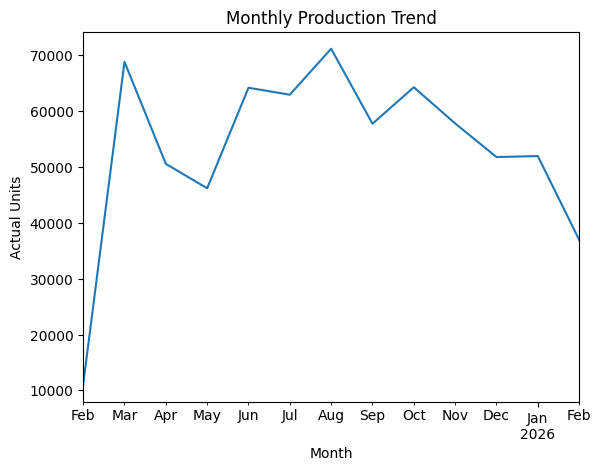

In [32]:
production['month'] = production['date'].dt.to_period('M')

monthly_prod = production.groupby('month')['actual_units'].sum()

print(monthly_prod)

monthly_prod.plot()
plt.title("Monthly Production Trend")
plt.xlabel("Month")
plt.ylabel("Actual Units")
plt.show()

shift
Evening    179460
Morning    176189
Night      187941
general    152059
Name: actual_units, dtype: int64


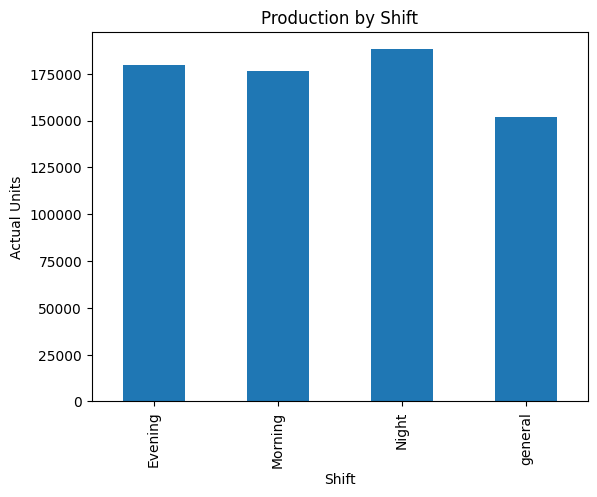

In [34]:
shift_perf = production.groupby('shift')['actual_units'].sum()

print(shift_perf)

shift_perf.plot(kind='bar')
plt.title("Production by Shift")
plt.xlabel("Shift")
plt.ylabel("Actual Units")
plt.show()

In [35]:
operator_perf = production.groupby('operator_id').agg({
    'actual_units': 'sum',
    'rejected_units': 'sum'
})

operator_perf['rejection_rate'] = (
    operator_perf['rejected_units'] /
    operator_perf['actual_units']
) * 100

print(operator_perf.sort_values(by='actual_units', ascending=False).head())

             actual_units  rejected_units  rejection_rate
operator_id                                              
55                  14406             262        1.818687
69                  14175             261        1.841270
63                  12560             253        2.014331
11                  12484             245        1.962512
20                  12167             254        2.087614


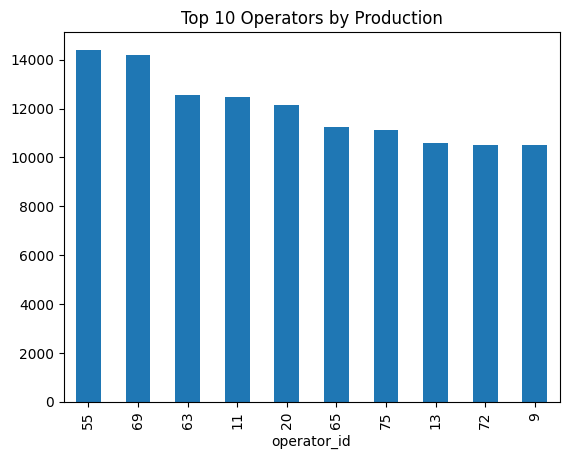

In [36]:
operator_perf['actual_units'].sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Operators by Production")
plt.show()

machine_id
33    384872
10    373202
25    325668
23    317027
19    315482
31    312693
29    309056
38    305133
27    295023
36    289569
30    285907
45    281324
28    276543
2     268550
14    264832
3     263858
34    251757
17    249562
37    249030
35    248984
11    248090
18    240973
16    233614
12    233236
6     232783
42    232486
20    232009
43    219880
24    218290
32    214696
15    211112
5     206922
13    200123
41    198678
8     193866
7     193108
44    189072
9     186283
22    169910
4     164459
21    163175
40    158030
39    149800
26    147419
1      92159
Name: maintenance_cost, dtype: int64


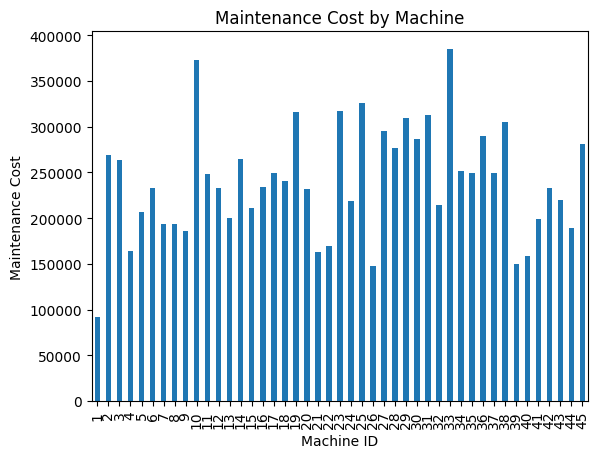

In [38]:
maintenance_cost = maintenance.groupby('machine_id')['maintenance_cost'].sum()

print(maintenance_cost.sort_values(ascending=False))

maintenance_cost.plot(kind='bar')
plt.title("Maintenance Cost by Machine")
plt.xlabel("Machine ID")
plt.ylabel("Maintenance Cost")
plt.show()